# Evaluate Generation on Unseen Protocols.

### Import Libraries.

In [1]:
import os
import sys
import yaml

from pathlib import Path 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scanpy as sc
from scipy.stats import gaussian_kde
from sklearn.preprocessing import LabelEncoder
import torch
from tqdm import tqdm
from omegaconf import OmegaConf


from labcompass.metrics import compute_e_distance
from labcompass.models import FlowMatching, TargetPredictionModel
from labcompass.constants import DataFields

import torch.nn.functional as F

sys.path.insert(0, "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/shared_utils")

### Plotting functions

In [2]:
def plot_ct_proportions(
    ct_prop_df,
    experiment_list,
    rename_map=None,
    dataset_palette=None,
    figsize=(4, 3),
    show_legend=True,
    compare_pre_post=False,
    break_yaxis=False,
    break_lower=(0, 0.2),
    break_upper=(0.85, 1.0), 
    save_path=None
):
    if rename_map is None:
        rename_map = {
            'CD14Mono': 'CD14Mono',
            'CD16Mono': 'CD16Mono',
            'EryPro': 'EryPro',
            'HSCs': 'HSCs',
            'ProB': 'ProB',
            'late_MgkPro': 'MgkPro',
            'preProB': 'preProB',
        }

    if not compare_pre_post:
        ct_prop_df = ct_prop_df.loc[ct_prop_df["Dataset type"] != "Predicted post loop 1"]
        dataset_palette = {
            "Predicted before experiments 205-210": "#e76f51",
            "Measured": "#264653",
        }
        hue_order = ["Predicted before experiments 205-210", "Measured"]
    else:
        dataset_palette = {
            "Predicted before experiments 205-210": "#2a9d8f",
            "Predicted after experiments 205-210": "#e76f51",
            "Measured": "#264653",
        }
        hue_order = ["Measured", "Predicted before experiments 205-210", "Predicted after experiments 205-210", ]

    ct_order = [rename_map[ct] for ct in rename_map] + ["Others"]

    def _to_list(param, n):
        if isinstance(param, list):
            if len(param) != n:
                raise ValueError(
                    f"Expected {n} values (one per experiment), got {len(param)}."
                )
            return param
        return [param] * n

    n = len(experiment_list)
    break_yaxis_list = _to_list(break_yaxis, n)
    break_lower_list = _to_list(break_lower, n)
    break_upper_list = _to_list(break_upper, n)

    for i, experiment_id in enumerate(experiment_list):
        lower = break_lower_list[i]
        upper = break_upper_list[i]
        use_break = break_yaxis_list[i] and lower is not None and upper is not None

        ct_prop_df_exp = ct_prop_df[ct_prop_df["Experiment number"] == experiment_id].copy()

        ct_prop_df_exp["Cell type"] = ct_prop_df_exp["Cell type"].apply(
            lambda x: rename_map.get(x, "Others")
        )

        ct_prop_df_exp = (
            ct_prop_df_exp
            .groupby(["Cell type", "Dataset type"], as_index=False)["Proportion"]
            .sum()
        )

        if use_break:
            lower_range = lower[1] - lower[0]
            upper_range = upper[1] - upper[0]

            fig, (ax_top, ax_bot) = plt.subplots(
                2, 1, figsize=figsize, sharex=True,
                gridspec_kw={
                    "height_ratios": [upper_range, lower_range],
                    "hspace": 0.05
                }
            )

            for ax in (ax_top, ax_bot):
                sns.barplot(ct_prop_df_exp, x="Cell type", y="Proportion", hue="Dataset type",
                            order=ct_order, hue_order=hue_order, palette=dataset_palette, ax=ax)
                ax.legend_.remove()

            ax_top.set_ylim(upper)
            ax_bot.set_ylim(lower)

            ax_top.spines["bottom"].set_visible(False)
            ax_bot.spines["top"].set_visible(False)
            ax_top.tick_params(bottom=False)

            d = 0.015
            kwargs = dict(transform=ax_top.transAxes, color="k", clip_on=False, linewidth=1)
            ax_top.plot((-d, +d), (-d, +d), **kwargs)
            ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)
            kwargs.update(transform=ax_bot.transAxes)
            ax_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)
            ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

            ax_top.set_title(f"Experiment {experiment_id}", fontsize=12)
            ax_top.set_xlabel("")
            ax_top.set_ylabel("")
            ax_bot.set_ylabel("")
            ax_bot.set_xlabel("")
            ax_top.tick_params(axis="y", labelsize=10, width=2)
            ax_bot.tick_params(axis="y", labelsize=10, width=2)
            ax_bot.tick_params(axis="x", labelrotation=90, labelsize=10, width=2)

            fig.text(0.01, 0.5, "Proportion", va="center", ha="center",
                     rotation="vertical", fontsize=10)

            if show_legend:
                ax_top.legend(fontsize=10, title_fontsize=10,
                              bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)

        else:
            fig, ax = plt.subplots(figsize=figsize)
            sns.barplot(ct_prop_df_exp, x="Cell type", y="Proportion", hue="Dataset type",
                        order=ct_order, hue_order=hue_order, palette=dataset_palette, ax=ax)
            ax.tick_params(axis="x", labelrotation=90, labelsize=10)
            ax.tick_params(axis="y", labelsize=10)
            ax.set_xlabel("")
            ax.set_ylabel("Proportion", fontsize=10)
            ax.set_title(f"Experiment {experiment_id}", fontsize=12)

            if show_legend:
                ax.legend(fontsize=10, title_fontsize=10,
                          bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)
            else:
                ax.legend_.remove()

        # plt.tight_layout()
        if save_path is not None:
            plt.savefig(f"{save_path}/experiment_{experiment_id}.svg", format="svg", bbox_inches="tight")
        plt.show()

### Load adata 

Initialize the dictionary containing the predictions from the model as well as real proportions.

In [3]:
ct_prop_dict = {
    "Experiment number": [], 
    "Cell type": [], 
    "Proportion": [],
    "Dataset type": []
}

Read the data

In [4]:
adata_loop1 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_filtered_.h5ad")
adata_loop1.obs["cell_type"] = adata_loop1.obs["cell_type"].astype(str)

unique_ct = np.unique(adata_loop1.obs["cell_type"])
unique_ct

array(['CD14Mono', 'CD16Mono', 'CyclingPro1', 'CyclingPro2', 'Early_GMP',
       'EosBasMast1', 'EosBasMast2', 'EosBasMast3', 'EryPro',
       'GMP-Neutro', 'GMP_cycling', 'HSCs', 'LMPP-CLP', 'MLP', 'MPP',
       'MPP_MgkEry', 'MgKEryPro1', 'MgKEryPro2', 'ProB', 'earlyMPP',
       'late_MgkPro', 'preProB', 'pre_cDC1', 'pre_cDC2'], dtype=object)

Separate loop 0 and 1

In [5]:
experiment_list = [205, 206, 207, 208, 209, 210]
adata_loop0 = adata_loop1[~adata_loop1.obs["experiment_number"].isin(experiment_list)]
adata_loop1 = adata_loop1[adata_loop1.obs["experiment_number"].isin(experiment_list)]

print(adata_loop0.shape)
print(adata_loop1.shape)

(449218, 20)
(22618, 20)


## Plot proportions

In [6]:
prop_array = []

for exp in experiment_list:
    adata_loop1_exp = adata_loop1[adata_loop1.obs.experiment_number == exp]
    ct_prop = adata_loop1_exp.obs.cell_type.value_counts() / adata_loop1_exp.shape[0]

    for ct in unique_ct:
        if ct not in ct_prop:
            ct_prop[ct] = 0.0

    # Reorder
    ct_prop = ct_prop[unique_ct]
    prop_array.append(ct_prop.values)

    for ct in ct_prop.index:
        ct_prop_dict["Experiment number"].append(exp)
        ct_prop_dict["Cell type"].append(ct)
        ct_prop_dict["Proportion"].append(ct_prop[ct])
        ct_prop_dict["Dataset type"].append("Measured")

prop_array = np.stack(prop_array)

### Load results pre/post measurements

In [7]:
le_ct = LabelEncoder().fit(adata_loop1.obs["cell_type"].astype(str))
id2_ct = dict(zip(le_ct.transform(le_ct.classes_),le_ct.classes_)) 

Read dumped results 

In [8]:
result_pre_path = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/forward/flow_matching/requested_protocols/2026-06-05_01-27-40_0271365f/")
result_post_path = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/forward/flow_matching/requested_protocols/2026-06-05_01-34-27_ce50ae36/")

results_pre = np.load(result_pre_path / "fwd_results.npz")
results_post = np.load(result_post_path / "fwd_results.npz")

In [9]:
results_argmax_pre = unique_ct[results_pre["ct_probs"].argmax(-1).T]
results_argmax_post = unique_ct[results_post["ct_probs"].argmax(-1).T]

In [10]:
for (i, experiment_id) in enumerate(experiment_list):
    # Process results
    ct_experiment_pre = pd.Series(results_argmax_pre[i])
    ct_experiment_post = pd.Series(results_argmax_post[i])
    # Normalize
    n_experiment = len(ct_experiment_pre)
    ct_experiment_pre_prop = ct_experiment_pre.value_counts() / n_experiment
    ct_experiment_post_prop = ct_experiment_post.value_counts() / n_experiment
    
    for ct in unique_ct:
        if ct not in ct_experiment_pre_prop.index:
            ct_experiment_pre_prop[ct] = 0.0
        if ct not in ct_experiment_post_prop.index:
            ct_experiment_post_prop[ct] = 0.0

        ct_prop_dict["Experiment number"].append(experiment_id)
        ct_prop_dict["Experiment number"].append(experiment_id)
        ct_prop_dict["Cell type"].append(ct)
        ct_prop_dict["Cell type"].append(ct)
        ct_prop_dict["Proportion"].append(ct_experiment_pre_prop[ct])
        ct_prop_dict["Proportion"].append(ct_experiment_post_prop[ct])
        ct_prop_dict["Dataset type"].append("Predicted before experiments 205-210")
        ct_prop_dict["Dataset type"].append("Predicted after experiments 205-210")

In [11]:
ct_prop_df = pd.DataFrame(ct_prop_dict)

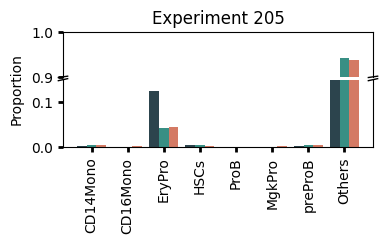

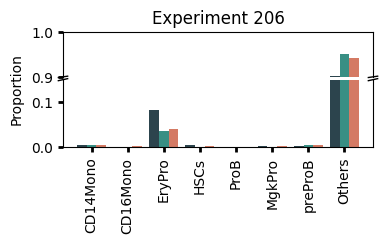

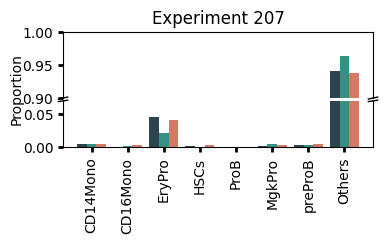

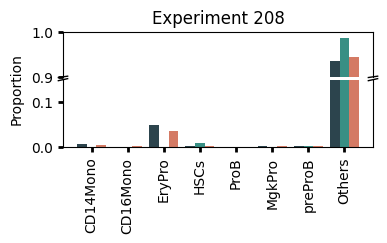

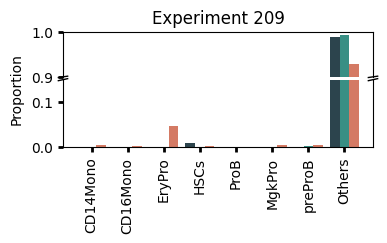

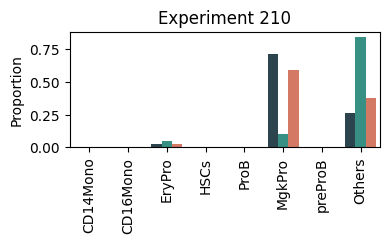

In [12]:
plot_ct_proportions(
    ct_prop_df,
    experiment_list, 
    compare_pre_post=True,
    figsize=(4, 1.5),
    break_yaxis=[True,
                 True, 
                 True, 
                 True,
                 True, 
                 False],
    break_lower=[(0, 0.15),
                 (0, 0.15),
                 (0, 0.07),
                 (0, 0.15),
                 (0, 0.15),
                 (0, 0.80)],
    break_upper=[(0.90, 1.0),
                 (0.90, 1.0),
                 (0.90, 1.0),
                 (0.90, 1.0),
                 (0.90, 1.0),
                 (0.90, 1.0)],
    save_path="./", show_legend=False
)

## Performance quality vs entropy

In [13]:
results_entropy_perf = {"Loss": [],
                        "Entropy": []}

for exp in np.unique(ct_prop_df["Experiment number"]):
    ct_prop_df_exp = ct_prop_df[ct_prop_df["Experiment number"] == exp]

    measured = ct_prop_df_exp[ct_prop_df_exp["Dataset type"] == "Measured"]
    measured = measured.set_index("Cell type")["Proportion"]

    predicted = ct_prop_df_exp[ct_prop_df_exp["Dataset type"] == "Predicted after experiments 205-210"]
    predicted = predicted.set_index("Cell type")["Proportion"]

    # sanity check: same cell types on both sides
    assert set(measured.index) == set(predicted.index), (
        f"Cell type mismatch in experiment {exp}: "
        f"{set(measured.index).symmetric_difference(set(predicted.index))}"
    )

    # align predicted to measured's order (avoids silent misalignment)
    predicted = predicted.reindex(measured.index)

    # cross-entropy-style performance metric (pandas aligns by index automatically)
    perf = -(measured * np.log(predicted)).sum()

    # entropy, guarding against log(0) -> -inf -> nan when multiplied by 0
    m = measured.values
    entropy = -np.sum(m[m > 0] * np.log(m[m > 0]))

    results_entropy_perf["Entropy"].append(entropy)
    results_entropy_perf["Loss"].append(perf)

In [14]:
results_entropy_perf = pd.DataFrame(results_entropy_perf)

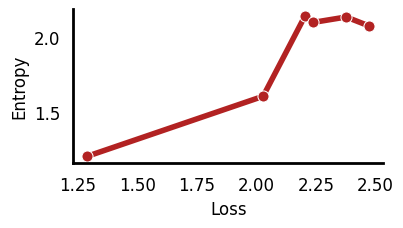

In [44]:
sns.set_theme(style="whitegrid", font_scale=1.1)

# sort by Loss so the line moves monotonically along the x-axis
plot_df = results_entropy_perf.sort_values("Loss").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(4,2))
sns.lineplot(
    data=plot_df,
    x="Loss",
    y="Entropy",
    marker="o",
    markersize=8,
    linewidth=4,
    color="firebrick",
    ax=ax,
)
ax.set_xlabel("Loss", fontsize=12, color="black")
ax.set_ylabel("Entropy", fontsize=12, color="black")

sns.despine(ax=ax)
ax.grid(False)

# make remaining spines black
for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(2)

# make ticks and tick labels black
ax.tick_params(axis="both", colors="black")

# plt.tight_layout()
plt.savefig("entropy_vs_loss.svg", format="svg", bbox_inches="tight")
plt.show()

In [49]:
plot_df

,Loss,Entropy
0,1.290584,1.208137
1,2.028606,1.608483
2,2.203716,2.142559
3,2.238854,2.101454
4,2.377421,2.137632
5,2.473758,2.077610


In [48]:
np.unique(ct_prop_df["Experiment number"])

array([205, 206, 207, 208, 209, 210])

## Check prediction total variance

In [16]:
from experiment_utils import (
    get_forward_model,
    get_target_dict, 
    get_loss_fn, 
    compute_exploitation_score, 
    compute_exploration_score, 
    compute_weighted_uncertainty_score, 
    compute_sequential_local_penalization
)

In [17]:
path_config_pre = result_pre_path / "config.yaml"
path_config_post = result_post_path / "config.yaml"

## Collect configurations and initialize models

In [18]:
with open(path_config_pre, "r") as f:
    config_pre = OmegaConf.load(f)

with open(path_config_post, "r") as f:
    config_post = OmegaConf.load(f)
    
protocol_cols = config_pre.annotation['protocol_columns']

config_dict = {"pre": config_pre, 
               "post": config_post}

Separate candidate to reference protocols

In [19]:
X_candidates = (
    adata_loop1.obs.sort_values("experiment_number")
    .loc[:, protocol_cols]
    .drop_duplicates()
    .values.astype(float)
)
X_candidates = np.log1p(X_candidates)

X_reference = (
    adata_loop0.obs.sort_values("experiment_number")
    .loc[:, protocol_cols]
    .drop_duplicates()
    .values.astype(float)
)
X_reference = np.log1p(X_reference)

Initialize the models

In [20]:
n_populations = 10

forward_models = {"pre": [], 
                  "post": []}

for lab, config in tqdm(config_dict.items()):
    forward_model, (_, target_prediction_model) = get_forward_model(
            config,
            logger=None
        )
    forward_models[lab] = forward_model

100%|██████████| 2/2 [03:02<00:00, 91.24s/it]


Perform predictions

In [21]:
predictions_var = {"pre": [],
                   "post": []}

predictions_mean = {"pre": [], 
                    "post": []}

with torch.no_grad():
    for _ in tqdm(range(20)):
        for lab, forward_model in forward_models.items():
            print(lab)
    
            X_candidates_pt = (
                torch.from_numpy(X_candidates)
                .float()
                .to(forward_model.device)
            )
    
            X_candidates_pt = (
                X_candidates_pt
                .unsqueeze(1)
                .repeat(1, 5000, 1)
            )
            
            condition_repr = next(
                iter(
                    forward_models[lab].forward_model.train_data.data.perturbation_covariates
                )
            )
    
            batch_dict = {
                DataFields.PERTURBATION_DATA: {
                    condition_repr: X_candidates_pt
                }
            }
    
            forward_out = forward_model.predict(
                batch_dict,
                no_grad=True,
                fix_noise=False,
                num_time_steps=100
            )
                
            # Collect predictions
            y_pred = (
                forward_out["target_prediction_data"]["cell_type"]
                .view(
                    X_candidates_pt.shape[0],
                    n_populations,
                    -1,
                    len(unique_ct)
                )
            )
    
            del forward_out
    
            # Shape:
            # (n_candidates, n_populations, n_samples, n_cell_types)
            y_pred_softmax = F.softmax(y_pred, dim=-1).mean(dim=2)
    
            # Shape:
            # (n_candidates, n_cell_types)
            y_pred_mean = (
                y_pred_softmax
                .mean(dim=1)
                .cpu()
                .numpy()
            )
            
            # Center across populations
            centered = y_pred_softmax - y_pred_softmax.mean(dim=1, keepdim=True)
            
            # Covariance matrix per candidate
            # Shape:
            # (n_candidates, n_cell_types, n_cell_types)
            y_pred_cov = (
                centered.transpose(1, 2) @ centered
            ) / (n_populations - 1)
            
            # Scalar uncertainty score (same interpretation as before:
            # trace of covariance matrix)
            # Shape:
            # (n_candidates,)
            y_pred_total_var = (
                y_pred_cov
                .diagonal(dim1=-2, dim2=-1)
                .sum(-1)
                .cpu()
                .numpy()
            )
    
            predictions_var[lab].append(y_pred_total_var)
            predictions_mean[lab].append(y_pred_mean)

  0%|          | 0/20 [00:00<?, ?it/s]

pre
post


  5%|▌         | 1/20 [00:15<04:47, 15.14s/it]

pre
post


 10%|█         | 2/20 [00:18<02:26,  8.14s/it]

...

 90%|█████████ | 18/20 [01:11<00:06,  3.33s/it]

pre
post


 95%|█████████▌| 19/20 [01:14<00:03,  3.33s/it]

pre
post


100%|██████████| 20/20 [01:18<00:00,  3.90s/it]


In [22]:
predictions_var_concat = {key: np.stack(val, axis=0) for key, val in predictions_var.items()}
predictions_mean_concat = {key: np.stack(val, axis=0).mean(0) for key, val in predictions_mean.items()}

Boxplots of variances 

In [23]:
variances_df_boxplot = {"Variance": [], 
                        "Stage": [],
                        "Experiment": []}

for stage in predictions_var_concat:
    for i, exp in enumerate(experiment_list):
        var_tmp = predictions_var_concat[stage][:, i]
        variances_df_boxplot["Variance"].append(var_tmp)
        variances_df_boxplot["Stage"].append([stage for _ in range(var_tmp.shape[0])])
        variances_df_boxplot["Experiment"].append([exp for _ in range(var_tmp.shape[0])])

In [24]:
variances_df_boxplot = {key: np.concat(val, axis=0) for key, val in variances_df_boxplot.items()}

<Axes: xlabel='Experiment', ylabel='Variance'>

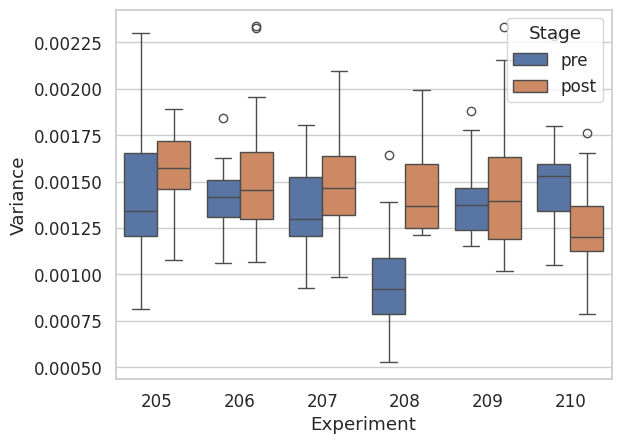

In [25]:
sns.boxplot(variances_df_boxplot, x="Experiment", y="Variance", hue="Stage")

### See how to handle the proportions

In [26]:
predictions_mean_concat["pre"].shape

(6, 24)

In [27]:
loss_pre = -(prop_array * np.log(predictions_mean_concat["pre"])).sum(-1)

In [28]:
loss_post = -(prop_array * np.log(predictions_mean_concat["post"])).sum(-1)

## Check improvement wrt distance from existing 

In [29]:
# Average log-dist
dist = ((X_candidates[:, None] - X_reference[None, :])**2).mean(-1)
average_dist = dist.mean(-1)
# Average standardized distance
means_reference = X_reference.mean(0)[None, :]
std_reference = X_reference.std(0)[None, :]

X_candidates_std = (X_candidates - means_reference) / std_reference
X_reference_std = (X_reference - means_reference) / std_reference

average_dist_std = ((X_candidates_std[:, None] - X_reference_std[None, :])**2).mean(-1).mean(-1)

In [30]:
df_loss_vs_dist = {
    "Loss": np.concat([loss_pre, loss_post]), 
    "Distance from existing recipes": np.concat([average_dist, average_dist]),
    "Distance from existing recipes std": np.concat([average_dist_std, average_dist_std]),
    "Dataset type": ["Loop 0" for _ in range(len(loss_pre))] + ["Loop 1" for _ in range(len(loss_pre))]
}

df_loss_vs_dist = pd.DataFrame(df_loss_vs_dist)

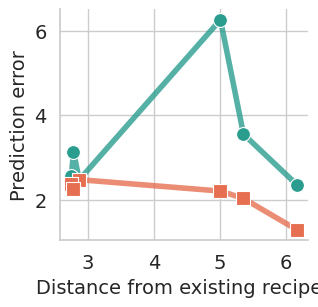

In [31]:
from statsmodels.nonparametric.smoothers_lowess import lowess

palette = {"Loop 0": "#2a9d8f", "Loop 1": "#e76f51"}
markers  = {"Loop 0": "o", "Loop 1": "s"}

fig, ax = plt.subplots(figsize=(3.2, 3))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for label, group in df_loss_vs_dist.groupby("Dataset type"):
    color = palette[label]

    ax.scatter(
        group["Distance from existing recipes"],
        group["Loss"],
        label=label,
        color=color,
        marker=markers[label],
        s=100,
        zorder=3,
        edgecolors="white",
        linewidths=0.8,
    )

    smoothed = lowess(
        group["Loss"],
        group["Distance from existing recipes"],
        frac=0.6
    )
    ax.plot(smoothed[:, 0], smoothed[:, 1], color=color, linewidth=4, alpha=0.8)

ax.set_xlabel("Distance from existing recipes", fontsize=14)
ax.set_ylabel("Prediction error", fontsize=14)
ax.tick_params(labelsize=14)
ax.spines[["top", "right"]].set_visible(False)
plt.savefig("loss_vs_dist.svg", format="svg", bbox_inches="tight")
# ax.legend(fontsize=12, frameon=True)
# plt.tight_layout()
plt.show()

# Boxplots - distances from training data 

In [32]:
boxplot_per_exp_dist = {"Experiment": [], 
                        "Dist": []}

for i in range(dist.shape[0]):
    boxplot_per_exp_dist["Experiment"].append([experiment_list[i] for _ in range(dist.shape[1])])
    boxplot_per_exp_dist["Dist"].append(dist[i])

In [33]:
boxplot_per_exp_dist_concat = {key: np.concatenate(val, axis=0) for key, val in boxplot_per_exp_dist.items()}

/tmp/ipykernel_2211181/2566104280.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


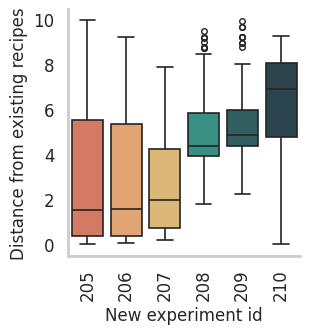

In [34]:
fig, ax = plt.subplots(figsize=(3, 3.2))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

experiment_colors = {
    205: "#e76f51",
    206: "#f4a261",
    207: "#ebbd68",
    208: "#2a9d8f",
    209: "#286569",
    210: "#264653",
}

experiments = sorted(np.unique(boxplot_per_exp_dist_concat["Experiment"]))
palette = [experiment_colors[e] for e in experiments]

sns.boxplot(
    data=boxplot_per_exp_dist_concat,
    x="Experiment",
    y="Dist",
    order=experiments,
    palette=palette,
    linewidth=1.2,
    flierprops=dict(marker="o", markerfacecolor="none", markersize=4, linewidth=0.8),
    ax=ax,
)

ax.set_xlabel("New experiment id", fontsize=12)
ax.set_ylabel("Distance from existing recipes", fontsize=12)
ax.tick_params(axis="x", labelsize=12, labelrotation=90, width=2)
ax.tick_params(axis="y", labelsize=12, width=2)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_linewidth(2)
ax.grid(False)

plt.savefig("boxplot_dist_per_experiment.svg", format="svg", bbox_inches="tight")
plt.show()